In [1]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from missforest import MissForest
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
import shap
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import cross_val_score
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from imblearn.metrics import specificity_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
# FUNCIONES
## Formato 5 decimales
pd.options.display.float_format = '{:,.5f}'.format 

## Metricas de clasificacion
def metricas_clas(y_train, y_test, y_pred_train, y_pred_test):
    # Calcular métricas para el conjunto de entrenamiento
    train_accuracy = accuracy_score(y_train, y_pred_train)
    train_f1 = f1_score(y_train, y_pred_train)
    train_precision = precision_score(y_train, y_pred_train)
    train_recall = recall_score(y_train, y_pred_train)
    train_specificity = specificity_score(y_train, y_pred_train)

    # Calcular métricas para el conjunto de prueba
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_specificity = specificity_score(y_test, y_pred_test)

    # Calcular la diferencia entre métricas de entrenamiento y prueba
    diff_accuracy = train_accuracy - test_accuracy
    diff_f1 = train_f1 - test_f1
    diff_precision = train_precision - test_precision
    diff_recall = train_recall - test_recall
    diff_specificity = train_specificity - test_specificity

    # Crear un DataFrame con los resultados
    metrics_df = pd.DataFrame([[train_accuracy,train_recall,train_specificity,train_precision,train_f1],
                               [test_accuracy, test_recall, test_specificity, test_precision,test_f1],
                               [diff_accuracy, diff_recall, diff_specificity, diff_precision, diff_f1]],
                              columns = ['Accuracy', 'Recall', 'Specificity', 'Precision', 'F1'],
                              index = ['Train','Test', 'Diferencia'])

    return metrics_df

# **0. CONTEXTO Y CARGA DATOS**

Fuente: https://github.com/4GeeksAcademy/logistic-regression-project-tutorial/blob/main/README.es.md

Descripción de variables:

- age. Edad del cliente (numérico)

- job. Tipo de trabajo (categórico)

- marital. Estado civil (categórico)

- education. Nivel de educación (categórico)

- default. ¿Tiene crédito actualmente? (categórico)

- housing. ¿Tiene un préstamo de vivienda? (categórico)

- loan. ¿Tiene un préstamo personal? (categórico)

- contact. Tipo de comunicación de contacto (categórico)

- month. Último mes en el que se le ha contactado (categórico)

- day_of_week. Último día en el que se le ha contactado (categórico)

- duration. Duración del contacto previo en segundos (numérico)

- campaign. Número de contactos realizados durante esta campaña al cliente (numérico)

- pdays. Número de días que transcurrieron desde la última campaña hasta que fue contactado (numérico)

- previous. Número de contactos realizados durante la campaña anterior al cliente (numérico)

- poutcome. Resultado de la campaña de marketing anterior (categórico)

- emp.var.rate. Tasa de variación del empleo. Indicador trimestral (numérico)

- cons.price.idx. Índice de precios al consumidor. Indicador mensual (numérico)

- cons.conf.idx. Índice de confianza del consumidor. Indicador mensual (numérico)

- euribor3m. Tasa EURIBOR 3 meses. Indicador diario (numérico)

- nr.employed. Número de empleados. Indicador trimestral (numérico)

- y. TARGET. El cliente contrata un depósito a largo plazo o no (categórico)

In [3]:
#Cargamos la base de datos en crudo
df=pd.read_csv("https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv", sep=";")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.10000,93.99400,-36.40000,4.85700,"5,191.00000",no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.10000,93.99400,-36.40000,4.85700,"5,191.00000",no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.10000,93.99400,-36.40000,4.85700,"5,191.00000",no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.10000,93.99400,-36.40000,4.85700,"5,191.00000",no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.10000,93.99400,-36.40000,4.85700,"5,191.00000",no


# **1. CRIBADO MANUAL**

## 1.1. Verificar valores

### 1.1.1. Unicos

In [5]:
# Valores unicos por cada columna
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


### 1.1.2. Eliminación de filas y columnas duplicadas

In [6]:
fil_dup=df.duplicated(keep="last") # keep=last: Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

Hay 12 filas duplicadas


In [7]:
#Mostramos un df con todas las filas duplicadas
todas=df.duplicated(keep=False)
df.iloc[todas[todas==True].index].T

,1265,1266,12260,12261,14155,14234,16819,16956,18464,18465,...,25183,25217,28476,28477,32505,32516,36950,36951,38255,38281
age,39,39,36,36,27,27,47,47,32,32,...,39,39,24,24,35,35,45,45,71,71
job,blue-collar,blue-collar,retired,retired,technician,technician,technician,technician,technician,technician,...,admin.,admin.,services,services,admin.,admin.,admin.,admin.,retired,retired
marital,married,married,married,married,single,single,divorced,divorced,single,single,...,married,married,single,single,married,married,married,married,single,single
education,basic.6y,basic.6y,unknown,unknown,professional.course,professional.course,high.school,high.school,professional.course,professional.course,...,university.degree,university.degree,high.school,high.school,university.degree,university.degree,university.degree,university.degree,university.degree,university.degree
default,no,no,no,no,no,no,no,no,no,no,...,no,no,no,no,no,no,no,no,no,no
housing,no,no,no,no,no,no,yes,yes,yes,yes,...,no,no,yes,yes,yes,yes,no,no,no,no
loan,no,no,no,no,no,no,no,no,no,no,...,no,no,no,no,no,no,no,no,no,no
contact,telephone,telephone,telephone,telephone,cellular,cellular,cellular,cellular,cellular,cellular,...,cellular,cellular,cellular,cellular,cellular,cellular,cellular,cellular,telephone,telephone
month,may,may,jul,jul,jul,jul,jul,jul,jul,jul,...,nov,nov,apr,apr,may,may,jul,jul,oct,oct
day_of_week,thu,thu,thu,thu,mon,mon,thu,thu,thu,thu,...,tue,tue,tue,tue,fri,fri,thu,thu,tue,tue


In [8]:
#Eliminamos las filas duplicadas
df.drop_duplicates(keep="last", inplace=True)
## Verificamos que se han eliminado correctamente
fil_dup=df.duplicated(keep="last") #Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

No hay filas duplicadas


In [9]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
col_dup=df.T.duplicated(keep="last")
print("No hay variables exactamente iguales" if col_dup.sum()==0 else f"Hay {fil_dup.sum()} variables exactamente iguales")

No hay variables exactamente iguales


## 1.2. Verificar missing values

### 1.2.1. Datos enmascarados(categoricas)

In [10]:
#Datos enmascarados (variables categoricas)
columnas=df.select_dtypes(include='object').drop(columns="y", axis=1)
for col in columnas:
    print("-"*20)
    print(f"Columna: {col}")
    print("-"*20)
    print(df[col].value_counts(normalize=True)*100)

--------------------
Columna: job
--------------------
job
admin.          25.30357
blue-collar     22.47183
technician      16.36633
services         9.63425
management       7.10122
retired          4.17233
entrepreneur     3.53604
self-employed    3.45104
housemaid        2.57432
unemployed       2.46260
student          2.12502
unknown          0.80144
Name: proportion, dtype: float64
--------------------
Columna: marital
--------------------
marital
married    60.52312
single     28.08432
divorced   11.19827
unknown     0.19429
Name: proportion, dtype: float64
--------------------
Columna: education
--------------------
education
university.degree     29.54148
high.school           23.10084
basic.9y              14.68088
professional.course   12.72586
basic.4y              10.14183
basic.6y               5.56392
unknown                4.20148
illiterate             0.04371
Name: proportion, dtype: float64
--------------------
Columna: default
--------------------
default
no       

Se aprecia como los valores nulos aparecen como: ``unknown`` y ``nonexistent``

In [11]:
# Reemplazamos y visualizamos categorias anteriores por NaN
df.replace(["unknown", "nonexistent"], np.nan, inplace=True)

### 1.2.2. Datos enmascarados(numericos)

In [12]:
df.select_dtypes(["int64", "float64"]).describe().T

,count,mean,std,min,25%,50%,75%,max
age,"41,176.00000",40.02380,10.42068,17.00000,32.00000,38.00000,47.00000,98.00000
duration,"41,176.00000",258.31582,259.30532,0.00000,102.00000,180.00000,319.00000,"4,918.00000"
campaign,"41,176.00000",2.56788,2.77032,1.00000,1.00000,2.00000,3.00000,56.00000
pdays,"41,176.00000",962.46481,186.93710,0.00000,999.00000,999.00000,999.00000,999.00000
previous,"41,176.00000",0.17301,0.49496,0.00000,0.00000,0.00000,0.00000,7.00000
emp.var.rate,"41,176.00000",0.08192,1.57088,-3.40000,-1.80000,1.10000,1.40000,1.40000
cons.price.idx,"41,176.00000",93.57572,0.57884,92.20100,93.07500,93.74900,93.99400,94.76700
cons.conf.idx,"41,176.00000",-40.50286,4.62786,-50.80000,-42.70000,-41.80000,-36.40000,-26.90000
euribor3m,"41,176.00000",3.62129,1.73444,0.63400,1.34400,4.85700,4.96100,5.04500
nr.employed,"41,176.00000","5,167.03487",72.25136,"4,963.60000","5,099.10000","5,191.00000","5,228.10000","5,228.10000"


<Axes: xlabel='pdays', ylabel='Count'>

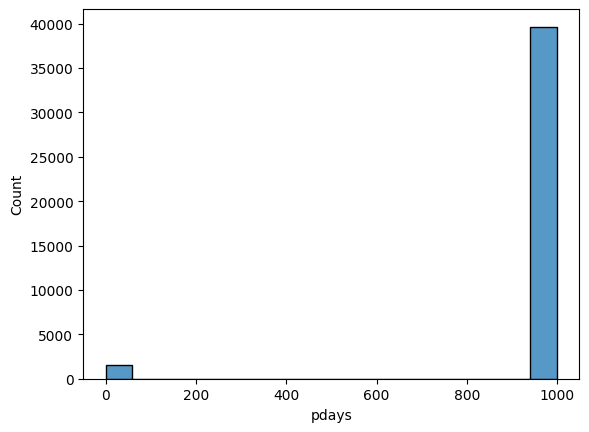

In [13]:
sns.histplot(data=df, x="pdays", bins="auto")

In [14]:
# Reemplazamos categorias anteriores por NaN
df["pdays"].replace(999, np.nan, inplace=True)

C:\Users\jjime\AppData\Local\Temp\ipykernel_7664\131291146.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["pdays"].replace(999, np.nan, inplace=True)


### 1.2.3. Visualización

In [15]:
#Mostramos columnas con valores nulos
nulos=df.isna().sum()/len(df)*100
nulos[nulos>0.1]

job          0.80144
marital      0.19429
education    4.20148
default     20.87624
housing      2.40431
loan         2.40431
pdays       96.32067
poutcome    86.33913
dtype: float64

[]

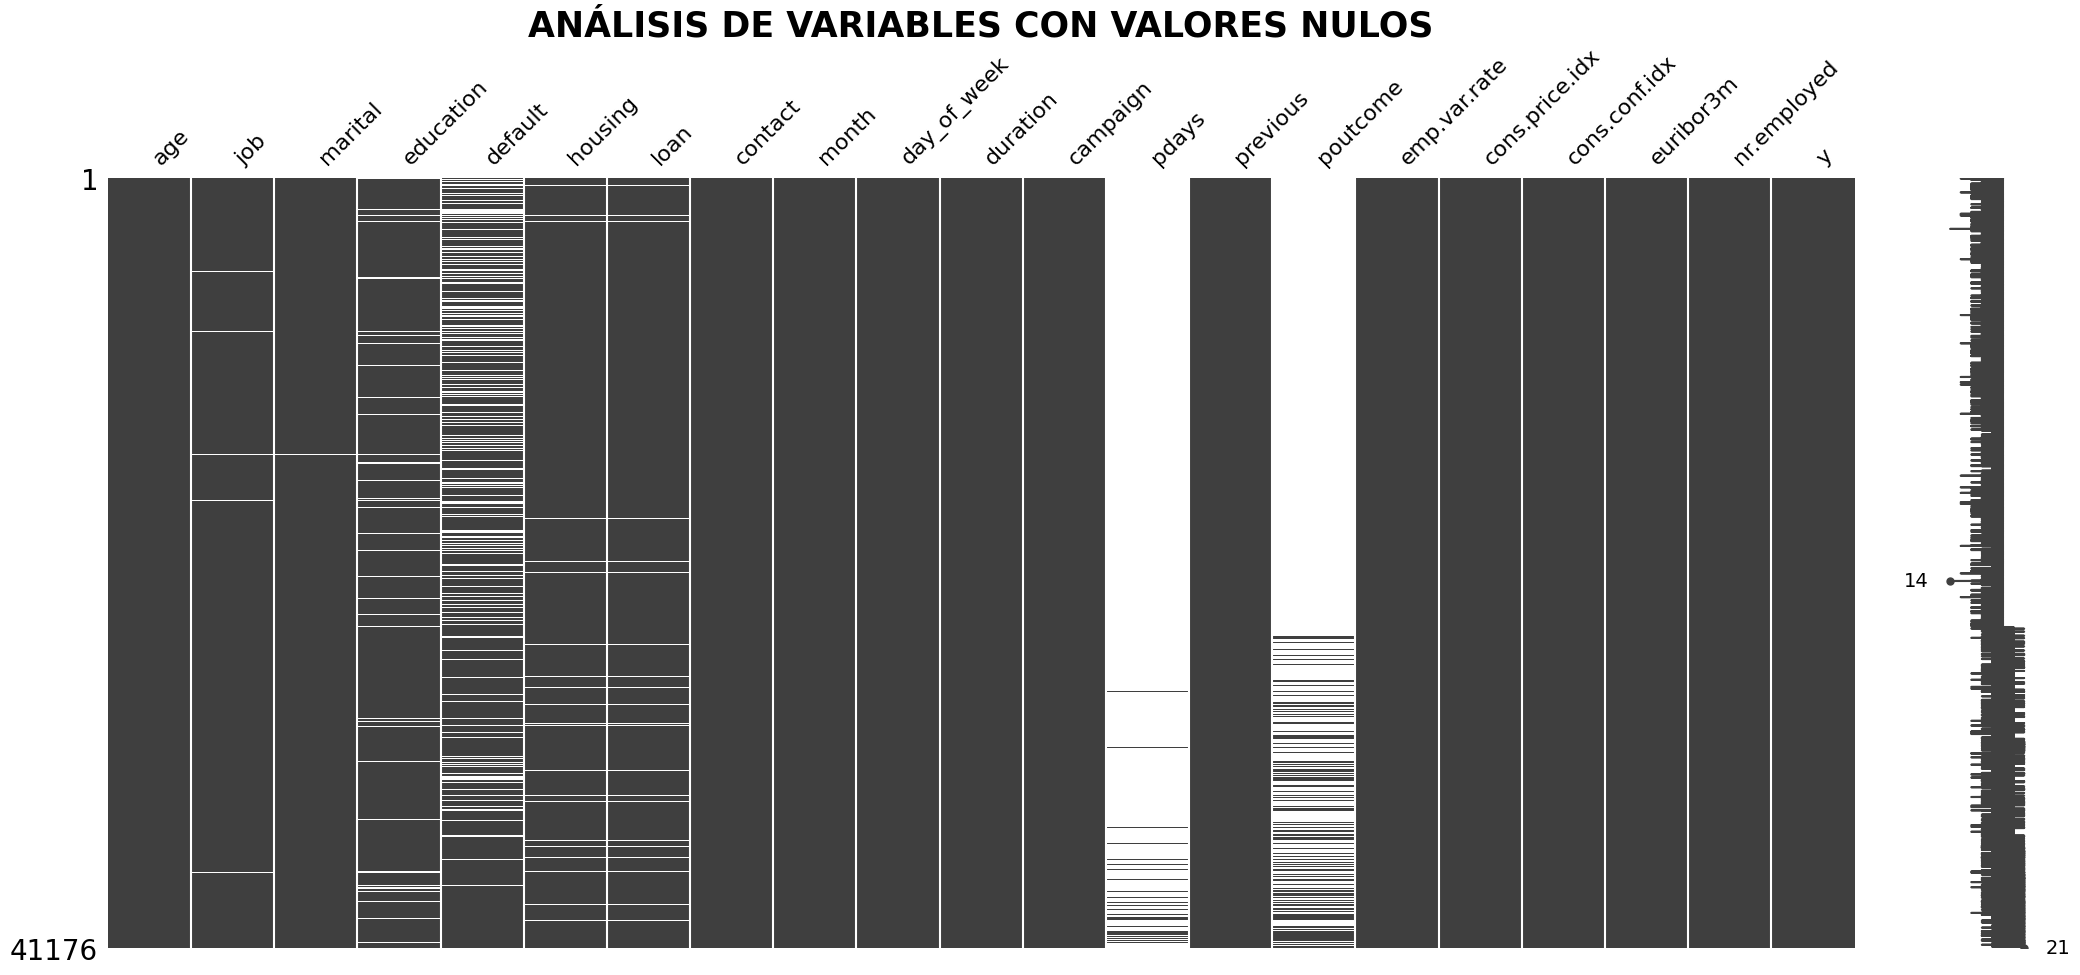

In [16]:
#Gráficamente
msno.matrix(df)
plt.title("ANÁLISIS DE VARIABLES CON VALORES NULOS", fontweight="bold", size=25)
plt.plot()

### 1.2.4. Eliminación

#### 1.2.4.1. Columnas

In [17]:
#Columnas con más de un 40% de missing values
column=df.isna().sum()/len(df)*100
print("No hay filas con muchas variables sin valores" if column[column>40].sum()==0 
      else f"Las columnas {column[column>40].index.to_list()} no aportan información")

Las columnas ['pdays', 'poutcome'] no aportan información


##### Análisis de ``poutcome``

In [18]:
#Valores unicos y distribución
print(df["poutcome"].unique())
print("\nVALORES NO NULOS:")
print(df["poutcome"].value_counts())
print("\nVALORES NULOS:")
print("nan", df[df["poutcome"].isna()].shape[0])

[nan 'failure' 'success']

VALORES NO NULOS:
poutcome
failure    4252
success    1373
Name: count, dtype: int64

VALORES NULOS:
nan 35551


In [19]:
#Estos valores nulos signfican que las personas no fueron contactadas en la campaña anterior
print("Personas que no fueron contactadas en la campaña anterior\n",df[df["previous"]==0].shape[0])

Personas que no fueron contactadas en la campaña anterior
 35551


De esta forma, vamos a tranformar la variables a:

- 0: no compro en la campaña anterior (porque no quiso o no fue contactado)
- 1: compro en la campaña anterior

In [20]:
# Caracteristica compro en campaña anterior
df["y(-1)"]=df["poutcome"].map({np.nan: 0, "failure": 0, 'success': 1})
df["y(-1)"].value_counts()

y(-1)
0    39803
1     1373
Name: count, dtype: int64

#### 1.2.4.2 Filas

In [21]:
#Verificamos si hay filas con más de un 40% de missing values
filas=df.T.isna().sum()/len(df.T)*100
print("No hay filas con muchas variables sin valores" if filas[filas>40].sum()==0 
      else f"Hay {filas.sum()} filas con variables sin valores")

No hay filas con muchas variables sin valores


In [22]:
df.drop(columns=['pdays', 'poutcome'], axis=1, inplace=True)
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,y(-1)
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,0,1.10000,93.99400,-36.40000,4.85700,"5,191.00000",no,0
1,57,services,married,high.school,NaN,no,no,telephone,may,mon,149,1,0,1.10000,93.99400,-36.40000,4.85700,"5,191.00000",no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,0,1.10000,93.99400,-36.40000,4.85700,"5,191.00000",no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,0,1.10000,93.99400,-36.40000,4.85700,"5,191.00000",no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,0,1.10000,93.99400,-36.40000,4.85700,"5,191.00000",no,0


## 1.3. Codificar variables categoricas

Tipos de categoricas:

- Ordinal (hay orden implicito en los datos)
    - <u>Métodos</u>: ordinal encoding
- Nominal I (no hay orden, baja cardinalidad: 10 categorias)
    - <u>Métodos</u>: one hot encoding
- Nominal II (no hay orden, alta cardinalidad)
    - <u>Métodos</u>: proportion z test

In [23]:
# Visualizamos valores unicos y numero de categorías
for col in df.select_dtypes("object").drop(columns="y"):
    print(f"\n{'='*30}")
    print(f"COLUMNA: {col.upper()}")
    print(f"{'='*30}")
    
    # Valores únicos
    valores = df[col].dropna().unique() # → Elimina los NaN antes de obtener los valores únicos
    print(f"Número de categorías: {len(valores)}")
    print(f"Valores: {valores}\n")  


COLUMNA: JOB
Número de categorías: 11
Valores: ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'entrepreneur' 'student']


COLUMNA: MARITAL
Número de categorías: 3
Valores: ['married' 'single' 'divorced']


COLUMNA: EDUCATION
Número de categorías: 7
Valores: ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'university.degree' 'illiterate']


COLUMNA: DEFAULT
Número de categorías: 2
Valores: ['no' 'yes']


COLUMNA: HOUSING
Número de categorías: 2
Valores: ['no' 'yes']


COLUMNA: LOAN
Número de categorías: 2
Valores: ['no' 'yes']


COLUMNA: CONTACT
Número de categorías: 2
Valores: ['telephone' 'cellular']


COLUMNA: MONTH
Número de categorías: 10
Valores: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']


COLUMNA: DAY_OF_WEEK
Número de categorías: 5
Valores: ['mon' 'tue' 'wed' 'thu' 'fri']



In [24]:
# Vamos a dividir las categorias en dos grupos
onehot=[]
prop=[]

for col in df.select_dtypes("object").drop(columns="y"):
# Condicional para ordenar variables
    onehot.append(col) if df[col].nunique()<=5 else prop.append(col)  

print(f"Filas con menos de 5 categorias: {onehot}")
print(f"Filas con más de 5 categorias: {prop}")

Filas con menos de 5 categorias: ['marital', 'default', 'housing', 'loan', 'contact', 'day_of_week']
Filas con más de 5 categorias: ['job', 'education', 'month']


### 1.3.1. Target

In [25]:
# Llamamos a la función
## - drop='first' elimina una cat 
## - parse_output=False devuelve array
ohe = OneHotEncoder(sparse_output=False, drop='first', dtype=int) 

# Ajustamos y transformamos
encoded_y = ohe.fit_transform(df[["y"]]) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["y"])
y = pd.DataFrame(encoded_y, columns=nombre_col)
# Usamos merge para asegurarnos que se unen por el mismo indice
df=pd.merge(df, y, on=df.index, how='right').drop(columns=["y", "key_0"]).rename(columns={"y_yes": "y"})
# Mostramos resultados
df["y"].value_counts()

y
0    36537
1     4639
Name: count, dtype: int64

In [26]:
#Analizamos si comprar en la campaña anterior es significativo
resumen=df.groupby("y(-1)")["y"].agg(['count', 'sum', 'mean']).sort_values(by="mean", ascending=False)

''' 
Z test: Diferencia de proporciones
- H0: No hay diferencias en la proporciones de y por y(-1)
- H1: Hay diferencias en una de las proporciones
'''
# Seleccionamos casos totales y positivos por cada categoría
nobs=resumen["count"].to_list()
success=resumen["sum"].to_list()
z_stad,p=proportions_ztest(success, nobs)
# Resultado
alpha=0.025
print(f"No hay diferencia de proporciones. (p-valor={round(p*100,4)}%, alpha={alpha*100}%)" if p>alpha 
 else f"Hay diferencia de proporciones. (p-valor={round(p*100,4)}%, alpha={alpha*100}%)")


Hay diferencia de proporciones. (p-valor=0.0%, alpha=2.5%)


[]

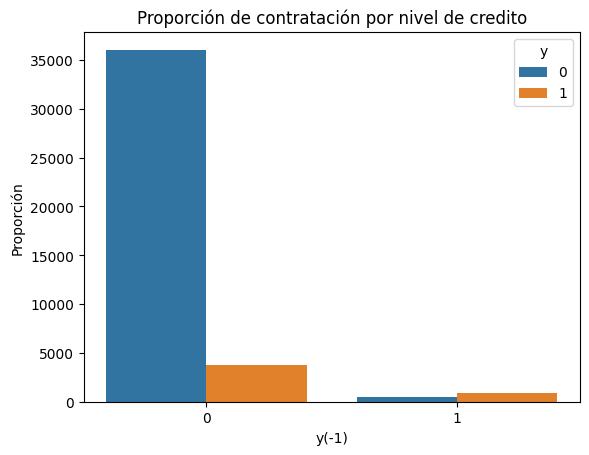

In [27]:
## Representacion
sns.countplot(data=df, x="y(-1)", hue="y")
plt.title("Proporción de contratación por nivel de credito")
plt.ylabel("Proporción")
plt.plot()

### 1.3.2. Menos de 5 categorias

#### A) Marital

[]

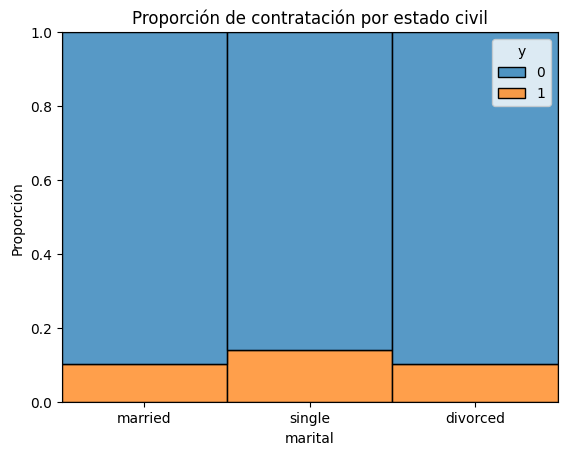

In [28]:
## Representacion
sns.histplot(data=df, x="marital", hue="y", multiple="fill")
plt.title("Proporción de contratación por estado civil")
plt.ylabel("Proporción")
plt.plot()

In [29]:
# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df[["marital"]]) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["marital"])
marital = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, marital, on=df.index, how='right').drop(columns=["marital", "marital_nan", "key_0"]).rename(columns={"marital_married": "maried", "marital_single": "single"})
df.columns

Index(['age', 'job', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'duration', 'campaign', 'previous',
       'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m',
       'nr.employed', 'y(-1)', 'y', 'maried', 'single'],
      dtype='object')

#### B) Default

In [30]:
#Testamos si la variable realmente es significativa
resumen=df.groupby("default")["y"].agg(['count', 'sum', 'mean']).sort_values(by="mean", ascending=False)


[]

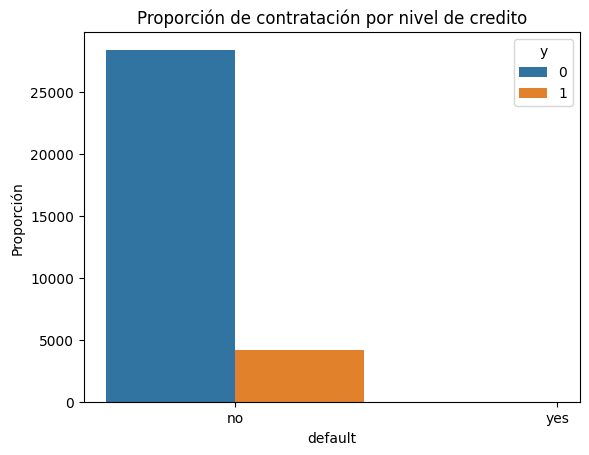

In [31]:
## Representacion
sns.countplot(data=df, x="default", hue="y")
plt.title("Proporción de contratación por nivel de credito")
plt.ylabel("Proporción")
plt.plot()

Se aprecia como, además de tener un 20% de valores nulos, la variable está excesivamente desbalanceada. De esta forma, realizaremos un ztest por cada categoría para ver si hay diferencias.

In [32]:
''' 
Z test: Diferencia de proporciones
- H0: No hay diferencias en la proporciones de y por default
- H1: Hay diferencias en una de las proporciones
'''
# Seleccionamos casos totales y positivos por cada categoría
nobs=resumen["count"].to_list()
success=resumen["sum"].to_list()
z_stad,p=proportions_ztest(success, nobs)
# Resultado
alpha=0.025
print(f"No hay diferencia de proporciones. (p-valor={round(p*100,4)}%, alpha={alpha*100}%)" if p>alpha 
 else f"Hay diferencia de proporciones. (p-valor={round(p*100,4)}%, alpha={alpha*100}%)")

No hay diferencia de proporciones. (p-valor=50.5424%, alpha=2.5%)


Con toda esta información, podemos proceder a eliminar la variable.

In [33]:
df.drop(columns="default", axis=1, inplace=True)

#### C) Housing

[]

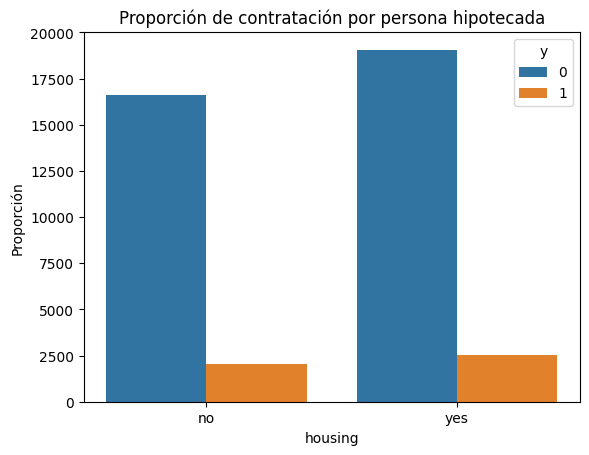

In [34]:
## Representacion
sns.countplot(data=df, x="housing", hue="y")
plt.title("Proporción de contratación por persona hipotecada")
plt.ylabel("Proporción")
plt.plot()

No se aprecia una diferencia significativa en la porporcion de compra en cada categoría. Vamos a testar si la variables es realmente significativa

In [35]:
#Testamos si la variable realmente es significativa
## Tabla de contingencia
resumen=df.groupby("housing")["y"].agg(['count', 'sum', 'mean']).sort_values(by="mean", ascending=False)
## Seleccionamos casos totales y positivos por cada categoría
nobs=resumen["count"].to_list()
success=resumen["sum"].to_list()
z_stad,p=proportions_ztest(success, nobs)
# Resultado
alpha=0.025
print(f"No hay diferencia de proporciones. (p-valor={round(p*100,4)}%, alpha={alpha*100}%)" if p>alpha 
    else f"Hay diferencia de proporciones. (p-valor={round(p*100,4)}%, alpha={alpha*100}%)")

Hay diferencia de proporciones. (p-valor=1.8754%, alpha=2.5%)


Una vez que sabemos que es significativa, vamos a hacer ohe.

In [36]:
# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df["housing"].to_frame()) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["housing"])
housing = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, housing, on=df.index, how='right').drop(columns=["housing", "housing_nan", "key_0"]).rename(columns={"housing_yes": "housing"})
df["housing"].value_counts()

housing
1    21571
0    19605
Name: count, dtype: int64

#### D) Loan

[]

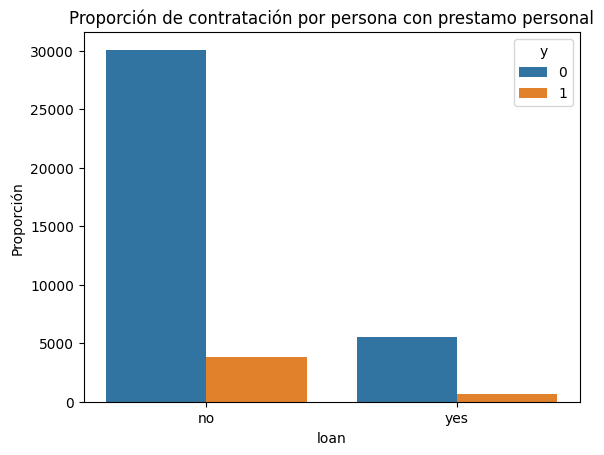

In [37]:
## Representacion
sns.countplot(data=df, x="loan", hue="y")
plt.title("Proporción de contratación por persona con prestamo personal")
plt.ylabel("Proporción")
plt.plot()

In [38]:
# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df["loan"].to_frame()) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["loan"])
loan = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, loan, on=df.index, how='right').drop(columns=["loan", "loan_nan", "key_0"]).rename(columns={"loan_yes": "loan"})
df["loan"].value_counts()

loan
0    34928
1     6248
Name: count, dtype: int64

#### E) Contact

[]

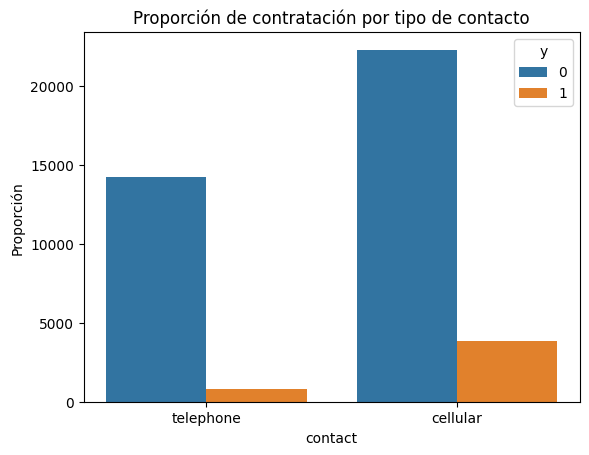

In [39]:
## Representacion
sns.countplot(data=df, x="contact", hue="y")
plt.title("Proporción de contratación por tipo de contacto")
plt.ylabel("Proporción")
plt.plot()

In [40]:
# Ajustamos y transformamos
encoded_data = ohe.fit_transform(df["contact"].to_frame()) 

# Añadimos al df
nombre_col = ohe.get_feature_names_out(["contact"])
contact = pd.DataFrame(encoded_data, columns=nombre_col)

df=pd.merge(df, contact, on=df.index, how='right').drop(columns=["contact", "key_0"]).rename(columns={"contact_telephone": "telephone"})
df["telephone"].value_counts()

telephone
0    26135
1    15041
Name: count, dtype: int64

#### F) Days_of_week

[]

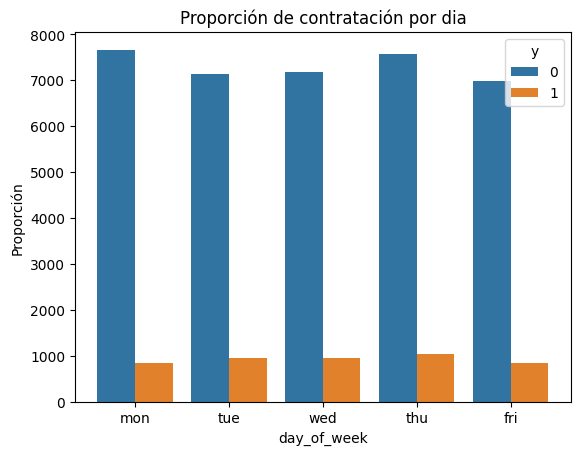

In [41]:
## Representacion
sns.countplot(data=df, x="day_of_week", hue="y")
plt.title("Proporción de contratación por dia")
plt.ylabel("Proporción")
plt.plot()

Vamos a verificar si hay diferencias en la proporcion de contraer el depósito por le dia de contacto

In [42]:
#Diferencia de proporcion de cotratacion por dia
print(df.groupby("day_of_week")["y"].mean())

#Test chi2
tabla=pd.crosstab(df["day_of_week"], df["y"])
chi2,p,dof,expected=stats.chi2_contingency(tabla)
print("="*30)
# Resultado
alpha=0.025
print(f"No hay diferencia de proporciones. (p-valor={round(p*100,4)}%, alpha={alpha*100}%)" if p>0.025 
    else f"Hay al menos diferencias de proporcion en un día. (p-valor={round(p*100,4)}%, alpha={alpha*100}%)")

day_of_week
fri   0.10810
mon   0.09951
thu   0.12114
tue   0.11786
wed   0.11667
Name: y, dtype: float64
Hay al menos diferencias de proporcion en un día. (p-valor=0.0031%, alpha=2.5%)


Como en esta variable si hay un orden implícito, realizaremso ordinal encoding.

In [43]:
# Definimos el orden lógico (de menor a mayor)
orden_logico = ["mon", "tue", "wed", "thu", "fri"]
# Instanciamos la funcion
ordenc = OrdinalEncoder(categories=[orden_logico], dtype=int)

# Ajustamos y transformamos
df["day_of_week"] = ordenc.fit_transform(df[["day_of_week"]])
df["day_of_week"].value_counts().sort_index()

day_of_week
0    8512
1    8086
2    8134
3    8618
4    7826
Name: count, dtype: int64

### 1.3.3. Más de 5 categorias

#### A) Month

[]

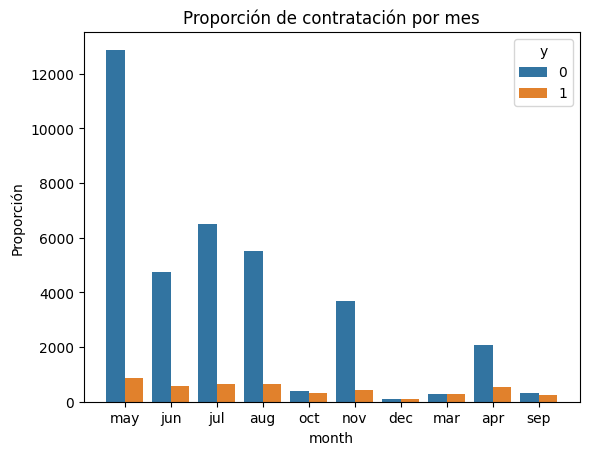

In [44]:
## Representacion
sns.countplot(data=df, x="month", hue="y")
plt.title("Proporción de contratación por mes")
plt.ylabel("Proporción")
plt.plot()

In [45]:
# Definimos el orden lógico (de menor a mayor)
orden_logico = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
# Instanciamos la funcion
ordenc = OrdinalEncoder(categories=[orden_logico], dtype=int)

# Transformamos
df["month"] = ordenc.fit_transform(df[["month"]])
df["month"].value_counts().sort_index()

month
0      546
1     2631
2    13767
3     5318
4     7169
5     6176
6      570
7      717
8     4100
9      182
Name: count, dtype: int64

#### B) Educación

[]

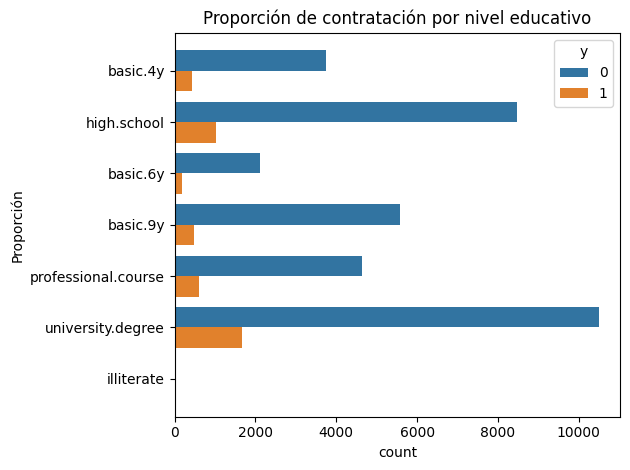

In [46]:
## Representacion
sns.countplot(data=df, y="education", hue="y")
plt.title("Proporción de contratación por nivel educativo")
plt.ylabel("Proporción")
plt.tight_layout()
plt.plot()

Vamos a estudiar el caso de ``illiterate``. Como en esta variable hay un orden lógico dentro de las variables, la compararemos con la más semejante

In [47]:
# tabla de contingencias
resumen=df.groupby("education")["y"].agg(['count', 'sum', 'mean']).sort_values(by="mean", ascending=False)
# illiterate y basic 4y
nobs=[resumen["count"].iloc[0], resumen["count"].iloc[4]] #Casos totales
success=[resumen["sum"].iloc[0], resumen["sum"].iloc[4]] #Casos positivos
z_stad,p=proportions_ztest(success, nobs)

# Resultado
alpha=0.025
print(f"No hay diferencia de proporciones. (p-valor={round(p*100,4)}%, alpha={alpha*100}%)" if p>alpha 
    else f"Hay diferencias de proporciones. (p-valor={round(p*100,4)}%, alpha={alpha*100}%)")

# Condicional para unir categorías 
if p>alpha:
    df["education"].replace({"illiterate": "basic.4y"}, inplace=True)

No hay diferencia de proporciones. (p-valor=9.5397%, alpha=2.5%)


C:\Users\jjime\AppData\Local\Temp\ipykernel_7664\3640924812.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["education"].replace({"illiterate": "basic.4y"}, inplace=True)


In [48]:
# Definimos el orden lógico (de menor a mayor)
orden_logico = ["basic.4y", "basic.6y", "basic.9y", "high.school", "professional.course", "university.degree"]
# Instanciamos la funcion
## - handle_unknown='use_encoded_value' trabajamos con NaN
## - unknown_value=-1 se codifican como -1 
ordenc = OrdinalEncoder(categories=[orden_logico], dtype=int, handle_unknown='use_encoded_value', unknown_value=-1)

# Transformamos
df["education"] = ordenc.fit_transform(df[["education"]])
df["education"].replace({-1: np.nan}, inplace=True)
df["education"].value_counts().sort_index()

C:\Users\jjime\AppData\Local\Temp\ipykernel_7664\3924638559.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["education"].replace({-1: np.nan}, inplace=True)


education
0.00000     4194
1.00000     2291
2.00000     6045
3.00000     9512
4.00000     5240
5.00000    12164
Name: count, dtype: int64

#### C) Job

El hecho de que ``job`` sea una variable nominal con un importante numero de categorias, nos incita a no utilizar one hot encoding y hacer que la base de datos se sobredimensione. De esta forma, vamos a establecer un "orden artifical" con Ordered Target Encoding.

No obstante, para evitar el *data leakage* los valores promedio de ``y`` que utilizaremos para dar orden, las categorías de ``job`` deben ser extraidos de train y copiados a test. Esto hace que test sea lo más imparcial posible.

## 1.5. División Train-Test

In [49]:
#Diviisón de la base de datos
X = df.drop('y',axis=1)
y = df['y']
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42) #random_state establece una semilla para que la division aleatoria sea la misma
X_train.head()

,age,job,education,month,day_of_week,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y(-1),maried,single,housing,loan,telephone
12346,29,entrepreneur,1.00000,4,4,286,3,0,1.40000,93.91800,-42.70000,4.95900,"5,228.10000",0,1,0,1,1,1
8564,50,admin.,5.00000,3,2,178,6,0,1.40000,94.46500,-41.80000,4.86400,"5,228.10000",0,0,1,0,0,1
21417,29,admin.,5.00000,5,1,103,4,0,1.40000,93.44400,-36.10000,4.96300,"5,228.10000",0,0,1,0,0,0
3315,35,admin.,5.00000,2,3,135,1,0,1.10000,93.99400,-36.40000,4.86000,"5,191.00000",0,0,1,0,0,1
33236,40,blue-collar,3.00000,2,1,418,1,0,-1.80000,92.89300,-46.20000,1.29100,"5,099.10000",0,0,1,0,0,0


### 1.5.1. Target Encoding

[]

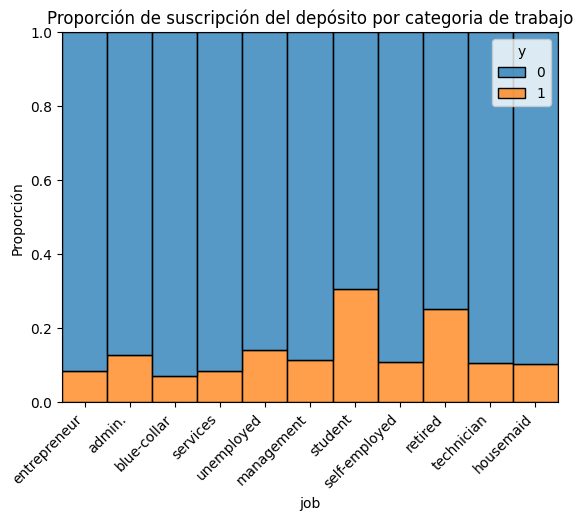

In [50]:
#Representacion gráfica
sns.histplot(x=X_train["job"], hue=y_train, multiple="fill") #multiple=fill expresa en procentajes
plt.title("Proporción de suscripción del depósito por categoria de trabajo")
plt.ylabel("Proporción")
plt.xticks(rotation=45, ha='right')
plt.plot()

Se aprecia como hay categorías con porporciones similares, por lo que vamos a testar si realmente hay diferencias entre ellas.

In [51]:
#Verificamos primero con Chi2 test
tabla=pd.crosstab(X_train["job"], y_train)

#Test de relación entre variables
chi2,p,dof,expected=stats.chi2_contingency(tabla) #El input para el test es la tabla de contingencias
#Resultado
alpha=0.025
print(f"No hay diferencia de proporciones entre las categorias de trabajo. (p-valor={round(p*100,4)}%, alpha={alpha*100}%)" if p>alpha 
    else f"Hay diferencias de proporciones en al menos una categoria de trabajo. (p-valor={round(p*100,4)}%, alpha={alpha*100}%)")

Hay diferencias de proporciones en al menos una categoria de trabajo. (p-valor=0.0%, alpha=2.5%)


Vamos a evaluar cuales son las categorias con diferencias importantes

In [52]:
#Agregamos variables para hacer .groupby
var_ana=pd.merge(X_train["job"], y_train, on=y_train.index)
resumen=var_ana.groupby("job")["y"].agg(['count', 'sum', 'mean']).sort_values(by="mean", ascending=False)
#Mostramos las proporciones media (%) por categoria
resumen["mean"]=resumen["mean"].round(3)*100
#Agregamos diferencia de proporciones
resumen["mean_diff"]=resumen["mean"].diff()
#Mostramos resultado
resumen

,count,sum,mean,mean_diff
job,,,,
student,682,208,30.50000,NaN
retired,1373,345,25.10000,-5.40000
unemployed,791,110,13.90000,-11.20000
admin.,8318,1062,12.80000,-1.10000
management,2362,269,11.40000,-1.40000
self-employed,1095,119,10.90000,-0.50000
technician,5399,563,10.40000,-0.50000
housemaid,868,88,10.10000,-0.30000
entrepreneur,1137,94,8.30000,-1.80000


In [53]:
#Mostramos categorias con como mucho 0.5 pp de diferencia
resumen[resumen["mean_diff"]>=-0.5]

,count,sum,mean,mean_diff
job,,,,
self-employed,1095,119,10.90000,-0.50000
technician,5399,563,10.40000,-0.50000
housemaid,868,88,10.10000,-0.30000
services,3187,262,8.20000,-0.10000


Categorias con máximo 0.5pp de diferencia:

- management, self-employed, technician, housemaid (test chi pues son correlativas) 

- entrepreneur y services (z_test)

In [54]:
#Verificamos primero con Chi2 test para las categorias correlativas
tabla=pd.crosstab(X_train["job"], y_train).loc[["management", "self-employed", "technician", "housemaid"]]

#Test de relación entre variables
chi2,p,dof,expected=stats.chi2_contingency(tabla) #El input para el test es la tabla de contingencias

#Resultado
alpha=0.025
print(f"No hay diferencia de proporciones entre las categorias de trabajo. (p-valor={round(p*100,4)}%, alpha={alpha*100}%)" if p>alpha 
    else f"Hay diferencias de proporciones en al menos una categoria de trabajo. (p-valor={round(p*100,4)}%, alpha={alpha*100}%)")

# Condicional para unir categorías 
if p>alpha:
    #train
    X_train["job"].replace({"management": "cat_igual", "self-employed": "cat_igual", "technician": "cat_igual", "housemaid": "cat_igual"}, inplace=True)
    #test
    X_test["job"].replace({"management": "cat_igual", "self-employed": "cat_igual", "technician": "cat_igual", "housemaid": "cat_igual"}, inplace=True)

No hay diferencia de proporciones entre las categorias de trabajo. (p-valor=59.1359%, alpha=2.5%)


C:\Users\jjime\AppData\Local\Temp\ipykernel_7664\3143342697.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train["job"].replace({"management": "cat_igual", "self-employed": "cat_igual", "technician": "cat_igual", "housemaid": "cat_igual"}, inplace=True)
C:\Users\jjime\AppData\Local\Temp\ipykernel_7664\3143342697.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never wo

In [55]:
# entrepreneur y services
nobs=resumen["count"].loc[["entrepreneur", "services"]].to_list()
success=resumen["sum"].loc[["entrepreneur", "services"]].to_list()
z_stad,p=proportions_ztest(success, nobs)

#Resultado
alpha=0.025
print(f"No hay diferencia de proporciones entre las categorias de trabajo. (p-valor={round(p*100,4)}%, alpha={alpha*100}%)" if p>alpha 
    else f"Hay diferencias de proporciones en al menos una categoria de trabajo. (p-valor={round(p*100,4)}%, alpha={alpha*100}%)")

# Condicional para unir categorías 
if p>alpha:
    #Train
    X_train["job"].replace({"entrepreneur": "cat_igual2", "services": "cat_igual2"}, inplace=True)
    #Test
    X_test["job"].replace({"entrepreneur": "cat_igual2", "services": "cat_igual2"}, inplace=True)


No hay diferencia de proporciones entre las categorias de trabajo. (p-valor=96.0964%, alpha=2.5%)


In [56]:
#Resultado de las categorias
var_ana=pd.concat([X_train["job"], y_train], axis=1)
job_enc=var_ana.groupby("job")["y"].mean().sort_values(ascending=False)
job_enc.sort_values()

job
blue-collar   0.06937
cat_igual2    0.08233
cat_igual     0.10685
admin.        0.12767
unemployed    0.13906
retired       0.25127
student       0.30499
Name: y, dtype: float64

In [57]:
# Definimos el orden haciendo uso del orden anterior
orden_seleccionado=job_enc.sort_values().index
# Instanciamos la funcion
ordenc = OrdinalEncoder(categories=[orden_seleccionado], dtype=int, handle_unknown='use_encoded_value', unknown_value=-1)

# Ajustamos y transformamos en train
X_train["job"] = ordenc.fit_transform(X_train[["job"]])
X_train["job"].replace({-1: np.nan}, inplace=True)
## Mostramos indices ordenados
print([float(i) for i in sorted(X_train["job"].unique())]) 
print("="*35)

#Transformamos test en base al ajuste de train
X_test["job"] = ordenc.fit_transform(X_test[["job"]])
## Mostramos indices ordenados
X_test["job"].replace({-1: np.nan}, inplace=True)
print([float(i) for i in sorted(X_test["job"].unique())]) 

[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, nan]
[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, nan, 6.0]


C:\Users\jjime\AppData\Local\Temp\ipykernel_7664\3270127639.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train["job"].replace({-1: np.nan}, inplace=True)
C:\Users\jjime\AppData\Local\Temp\ipykernel_7664\3270127639.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For ex

In [58]:
df.head()

,age,job,education,month,day_of_week,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y(-1),y,maried,single,housing,loan,telephone
0,56,housemaid,0.00000,2,0,261,1,0,1.10000,93.99400,-36.40000,4.85700,"5,191.00000",0,0,1,0,0,0,1
1,57,services,3.00000,2,0,149,1,0,1.10000,93.99400,-36.40000,4.85700,"5,191.00000",0,0,1,0,0,0,1
2,37,services,3.00000,2,0,226,1,0,1.10000,93.99400,-36.40000,4.85700,"5,191.00000",0,0,1,0,1,0,1
3,40,admin.,1.00000,2,0,151,1,0,1.10000,93.99400,-36.40000,4.85700,"5,191.00000",0,0,1,0,0,0,1
4,56,services,3.00000,2,0,307,1,0,1.10000,93.99400,-36.40000,4.85700,"5,191.00000",0,0,1,0,0,1,1


## 1.6. Imputación missing values

De nuevo para evitar el data leakage vamos a rellenar los NaN del Test usando los valores en el Train.

[]

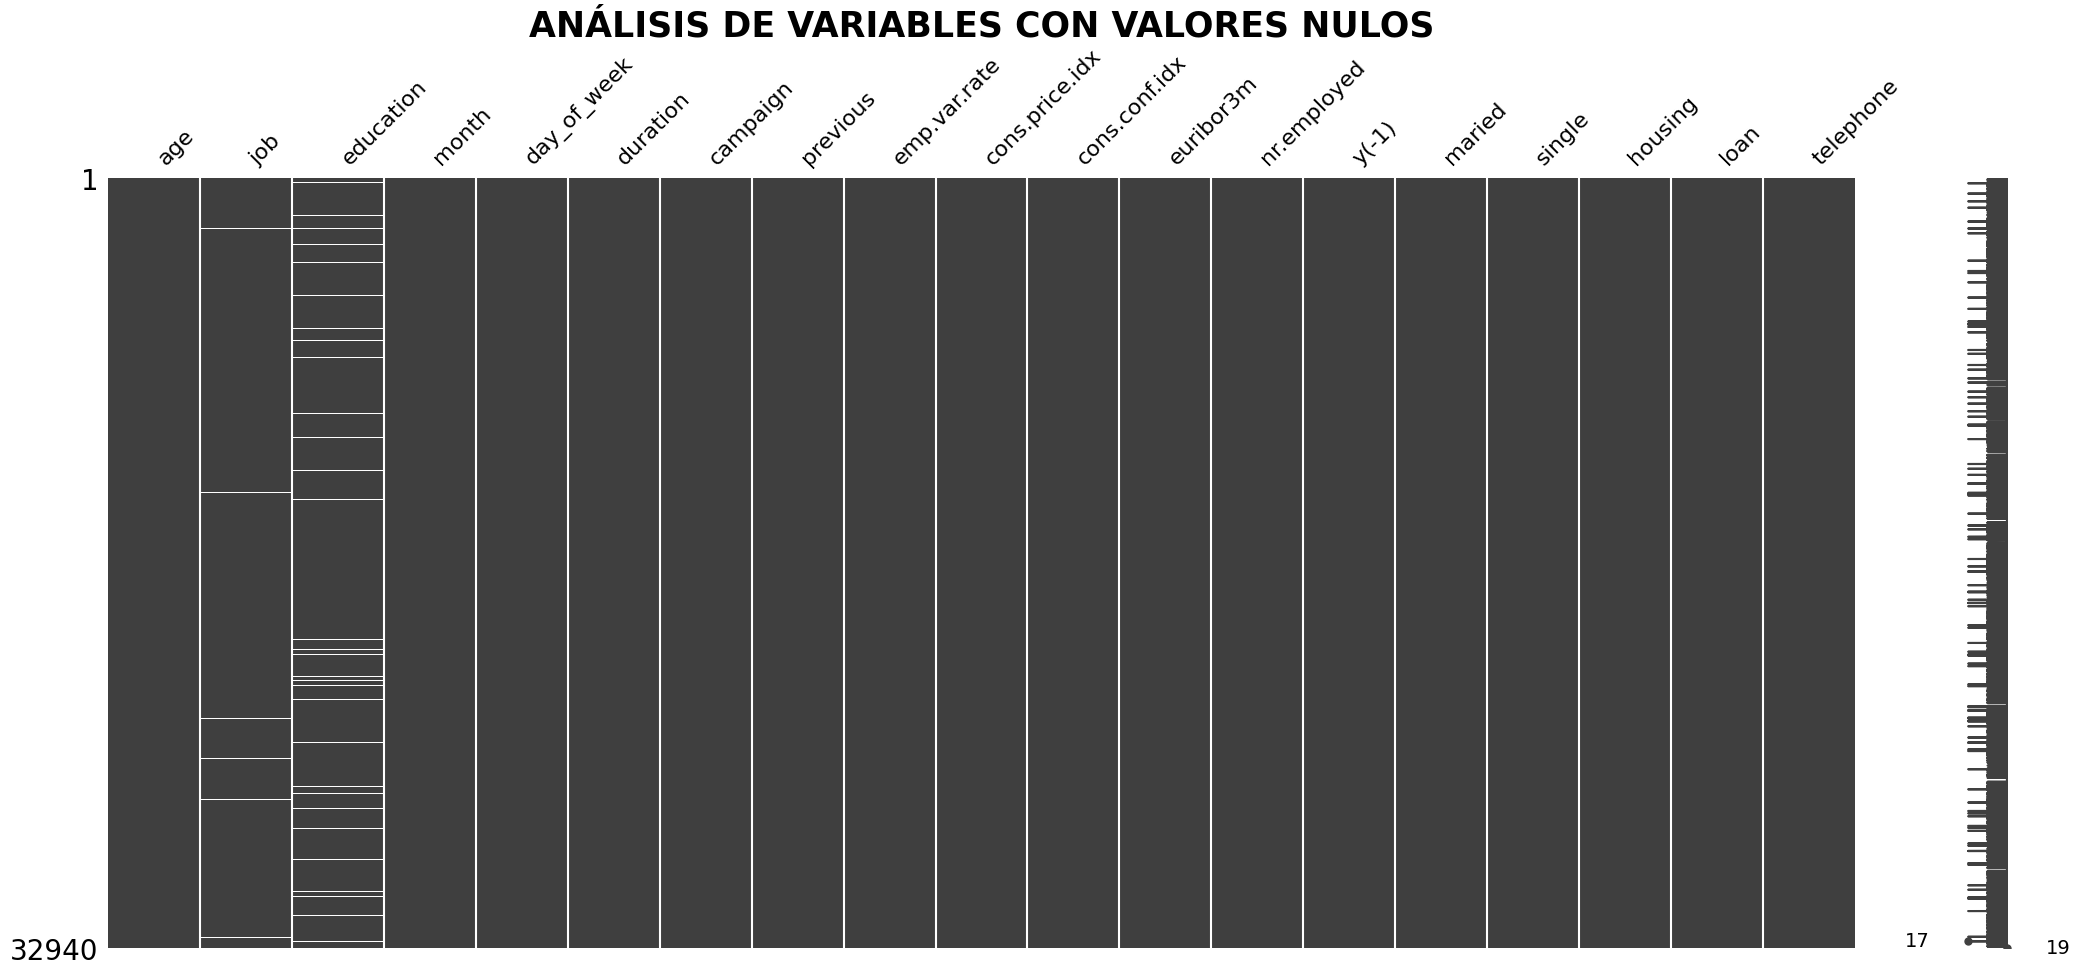

In [59]:
#Gráficamente
msno.matrix(X_train)
plt.title("ANÁLISIS DE VARIABLES CON VALORES NULOS", fontweight="bold", size=25)
plt.plot()

In [60]:
#Diferencia absoluta entre valores df y df con NaN
np.abs(df[df["education"].isna()==True].describe().T["mean"]-df[df["education"].isna()==False].describe().T["mean"])

age              3.61357
education            NaN
month            0.13599
day_of_week      0.07620
duration         4.35864
campaign         0.03051
previous         0.05593
emp.var.rate     0.02463
cons.price.idx   0.08637
cons.conf.idx    0.65416
euribor3m        0.05324
nr.employed      7.85501
y(-1)            0.01648
y                0.03385
maried           0.00359
single           0.00293
housing          0.01889
loan             0.01237
telephone        0.04891
Name: mean, dtype: float64

Parece que no hay ningun patron dentro de los NaN pues practicamente replican la distribución de la base de datos sin valores nulos.

In [61]:
# Variables con missing values
X_train.isna().sum()[X_train.isna().sum()>0]/len(X_train)*100

job         0.83485
education   4.21979
dtype: float64

In [ ]:
#Instanciamos MissForest
categorical=["job", "education", "month", "day_of_week", "maried", "single", "housing", "loan", "telephone", "y(-1)"]
imputer = MissForest(categorical=categorical)

#Base de datos train
## - .fit_transform() entrena el modelo y predice los valores faltantes
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns, index=X_train.index)

#Base de datos test
## - .transform() aplica el modelo anterior en unos nuevos datos
X_test_imp = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns, index=X_test.index)

c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\missforest\missforest.py:333: UserWarning: Label encoding is no longer performed by default. Users will have to perform categorical features encoding by themselves.
  warnings.warn("Label encoding is no longer performed by default. "
 60%|██████    | 3/5 [02:55<01:58, 59.32s/it]

In [ ]:
# Comprobamos eliminacion de missing values
X_train_imp.isna().sum()[X_train_imp.isna().sum()>0]/len(X_train_imp)*100

## 1.7. Análisis de outliers

### 1.7.1. Detección

In [ ]:
#Unimos bases de datos para mantener dimension x e y
train=pd.concat([X_train_imp, y_train], axis=1)
train.describe().T

In [ ]:
#Primer análisis de outliers (diferncia media-mediana)
variables=["age", "job", "education", "duration", "campaign"]
result=[]
for var in variables:
    result.append(np.abs(X_train[var].mean()-X_train[var].median())/X_train[var].median()*100)

outliers=pd.Series(result, index=variables)
outliers[outliers>20]

### 1.7.2. Winsorización

In [ ]:
# Histograma con para las variables con riesgo de outliers
fig, axis = plt.subplots(2, 2, figsize=(9, 6))

# Crear un histograma en el primer subplot
# Primera fila
sns.histplot(data=train, x="duration", bins=200, ax=axis[0,0]).set_ylabel(None)
sns.histplot(data=train, x="campaign", bins=100, ax=axis[0,1]).set_ylabel(None)
#Segunda filas
sns.boxplot(data=train, x="duration", ax=axis[1,0])
sns.boxplot(data=train, x="campaign", ax=axis[1,1])

# Mostrar la figura
plt.tight_layout()
plt.show()

In [ ]:
#Aplicamos winsorizacion:
## DURATION
sup_dur=train["duration"].quantile(0.99) #solo p99 pues tenemos distribución asimétrica
### Guardamos observaciones eliminadas
dur_elm=train["duration"][train["duration"]>sup_dur]/60
train=train[train["duration"]<sup_dur]

## CAMPAIGN
sup_cam=train["campaign"].quantile(0.995) #p99.5 pues tenemos distribución asimétrica
cam_elm=train["campaign"][train["campaign"]>sup_cam]
train=train[train["campaign"]<sup_cam]

#Observamos describe de las columnas eliminadas
## Duration
print("ELIMINADOS DURATION (minutos)\n",dur_elm.describe())
print("-"*30)
## Campaign
print("ELIMINADOS CAMPAIGN\n",cam_elm.describe())
print("="*30)
print(f"- {len(dur_elm)+len(cam_elm)} observaciones eliminadas")
print(f"- {(len(dur_elm)+len(cam_elm))/len(X_train_imp)*100: 0.2f}% de la muestra train")

In [ ]:
# Figura tras tratamiento
fig, axis = plt.subplots(2, 2, figsize=(9, 5))

# Crear un histograma en el primer subplot
# Primera fila
sns.boxplot(data=X_train_imp, x="duration", ax=axis[0,0])
sns.boxplot(data=X_train_imp, x="campaign", ax=axis[0,1])
axis[0, 0].set_title("Antes del tratamiento")

# Segunda fila
sns.boxplot(data=np.log(train), x="duration", ax=axis[1,0])
sns.boxplot(data=np.log(train), x="campaign", ax=axis[1,1])
axis[1, 0].set_title("Después de Winsorización y escala logaritmica")

# Mostrar la figura
fig.suptitle("Comparación de Distribuciones Antes y Después del Logaritmo", fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Aplicamos logaritmos en variables estudiadas con outliers

## TRAIN
#Dividimos de nuevo las x e y
X_train_sel=train.drop(columns=["y"])
y_train_sel=train["y"]
### Logaritmos
X_train_sel["duration"]=np.log1p(train["duration"]) #log1p=log(x+1) -> corrige log(0)
X_train_sel["campaign"]=np.log1p(train["campaign"])

## TEST
X_test_sel=X_test_imp.copy()
X_test_sel["duration"]=np.log1p(X_test_sel["duration"])
X_test_sel["campaign"]=np.log1p(X_test_sel["campaign"])

# **2. SELECCIÓN DE CARACTERÍSTICAS**

## 2.1. Aplicar métodos

### 2.1.1. Feature Importance

El **feature importance** en RandomForestClassifier se calcula mediante reducción de impureza promedio a través de todos los árboles del bosque.

Cómo se calcula:
1. Para cada árbol individual: Se mide cuánto reduce cada feature la impureza (Gini o entropía) cuando se usa para hacer splits

2. Ponderación por muestras: La reducción se pondera por el número de muestras que pasan por ese nodo

3. Promedio entre árboles: Se promedian las importancias de cada feature a través de todos los árboles del bosque

4. Normalización: Los valores finales se normalizan para que sumen 1
Fórmula de reducción de impureza:
La importancia de una feature se basa en esta ecuación (mencionada en el texto):

$\text{Reducción} = \frac{N_t}{N} I_t - \frac{N_{t_L}}{N} I_L - \frac{N_{t_R}}{N} I_R$

Donde:
- $N$: total de muestras

- $N_t$ y I_t: muestras e impureza en el nodo actual

- $N_{tL}$ y $I_{tL}$: muestras e impureza en hijos izquierdo

- $N_{tR}$ y $I_{tR}$: muestras e impureza en hijos derechos

Fuente: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

In [ ]:
# Entrenamiento de RF
model = RandomForestClassifier(random_state=42,n_jobs=-1).fit(X_train_sel, y_train_sel)
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100
# Mostramos resultados
df_rf_imp = pd.DataFrame({'feature': X_train_sel.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)
df_rf_imp

### 2.1.2. Permutation Importance

**Permutation importance** proporciona el cambio en la métrica de scoring seleccionada cuando alteramos los valores de las características de estudio. 

Como en nuestro caso estamos trabajando con información económica, vamos a centrarnos en la métrica de f1 score para minimizar FP en los que el banco estaria invirtiendo y realmente no son clientes, máximizando el numero de VP.

Informacion sobre scorings: https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-string-names

Fuente: https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html

In [ ]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train_sel, y_train_sel, test_size=0.2, random_state=42)
# Entrenamos el modelo que va a porporcionarnos las predicciones por cada alteracion
model_xgb = XGBClassifier(objective='binary:logistic', random_state=42).fit(X_train1, y_train1)
# Intanciamos permitation forest
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='f1')
## Extraemos los valores a un df
df_perm_imp = pd.DataFrame({'feature': X_train1.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm_imp

In [ ]:
# REPRESENTACIÓN GRÁFICA
## Orden de las variables (de menor a mayor importancia media):
### - asegura que el gráfico final esté ordenado
sorted_idx = perm.importances_mean.argsort()

## DataFrame para el Box Plot
### - perm.importances devuelve los n cambios en f1 de la caract x 
importances_df = pd.DataFrame(
    perm.importances[sorted_idx].T,
    columns=X_train_sel.columns[sorted_idx] 
)
importances_df

## Gráfico
fig, ax = plt.subplots(figsize=(9,6))

### Usamos .plot.box() directamente sobre el DataFrame (columna por columna)
ax = importances_df.plot.box(vert=False, whis=10, ax=ax) # vert=False -> gráfico horizontal
ax.set_title("Permutation Importances", fontsize=14)
ax.set_ylabel("Características")
ax.axvline(x=0, color="k", linestyle="--") # Línea vertical en 0 (sin ganancia/pérdida)
ax.set_xlabel("Disminución en métrica f1 (10 repeticiones)") 
fig.tight_layout()
plt.show()

### 2.1.3. SHAP

SHAP utiliza valores de Shapley de la teoría de juegos cooperativos para asignar crédito a cada característica. Los valores SHAP miden cuánto contribuye cada característica a la predicción del modelo, proporcionando una interpretación consistente del comportamiento del modelo. El explainer integra sobre múltiples muestras de fondo para estimar valores SHAP aproximados que suman la diferencia entre la salida esperada del modelo y la salida actual: $f(x) - E[f(x)]$ 

Fuente: https://shap.readthedocs.io/en/latest/generated/shap.Explainer.html#shap.Explainer

In [ ]:
# Ajustamos un modelo predictor para analizar la importancia de cada caract.
model_gbc = GradientBoostingClassifier(random_state=42).fit(X_train1, y_train1) 
# Instanciamos el shap explainer y extraemos los valores
explainer = shap.Explainer(model_gbc, X_val)  
shap_vals = explainer(X_val).values
# Pasamos los valores absolutos a un df
imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_train_sel.columns, "shap_imp": imp_shap_pct.round(3)}).sort_values('shap_imp', ascending=False)
df_shap_imp

## 2.2. Seleccionar variables

In [ ]:
#Añadimos resultados a un único df
df_importances = (
    df_rf_imp
    .merge(df_perm_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('perm_imp', ascending=False)

#Mostramos resultado
df_importances

In [ ]:
# Eliminamos aquellas con un permutation importance negativo
df_sel=df_importances[(df_importances["rf_importance"]>2)&(df_importances["shap_imp"]>1.8)]
df_sel

No vamos a aplicar filtrado en los valores de permutation para ver si ``age`` aporta información estadisiticamente significativa a nuestro modelo de regresión logística.

In [ ]:
# RESUMEN DE LA SELECCIÓN
## Eliminados
elm=df_importances["feature"][(df_importances["rf_importance"]<2)|(df_importances["shap_imp"]<1.8)].to_list()
## Seleccionados
sel=df_sel["feature"].tolist()

# Texto
print(f"{len(elm)} columnas eliminadas:")
print(elm)
print("-"*120)
print(f"{len(sel)} columnas seleccionadas:")
print(sel)

## 2.3. Comprobar vif y correlaciones

El VIF (variance inflation factor) cuantifica la intensidad de la multicolinealidad en un análisis de regresión normal de mínimos cuadrados.

- **Fórmula**: $\displaystyle \mathrm {FIV_{i}} ={\frac {1}{1-R_{i}^{2}}}$
    - donde R2i es el coeficiente de determinación de la ecuación de regresión del primer paso, con $\displaystyle X_{i}$ en el lado izquierdo y el resto de variables predictivas en el derecho.

In [ ]:
# VIF
## Variable Xi: añdimos cte. para no asumir que regresión pasa por (0,0) y tener problemas con R2 de vif
x_vif=add_constant(X_train_sel[sel])

## Cálculo: x_vif.values (array con los datos), i valor de la columna que asuma Yi
vif = pd.Series([variance_inflation_factor(x_vif.values, i) for i in range(x_vif.shape[1])], index=x_vif.columns).drop(index="const")
vif[vif>5]

Análisis:

- VIF <= 1: Ausencia de multicolinealidad. El predictor no está correlacionado con otros predictores, por lo que no infla el error típico ni afecta a la estabilidad del modelo.

- VIF entre 1 y 5: Multicolinealidad moderada. Existe cierta correlación con otros predictores, pero no suele ser grave.

- VIF > 5: Riesgo multicolinealidad. El error típico del predictor puede estar notablemente inflado, lo que puede hacer que su coeficiente sea menos fiable. Considera la posibilidad de tomar medidas para reducir la multicolinealidad, como eliminar o combinar los predictores correlacionados.

- VIF > 10: Multicolinealidad grave. El error típico del predictor está muy inflado y la estimación de su coeficiente es probablemente inestable. Suelen ser necesarias acciones correctoras, como eliminar el predictor o utilizar técnicas de regularización.

In [ ]:
#Análisis de correlaciones entre regresores
x_vif.drop(columns="const", axis=1, inplace=True)
x_vif['y'] = y_train_sel
corr = x_vif.corr()

#Mapa de correlaciones
plt.figure(figsize=(10, 5))
sns.heatmap(
    corr, mask=np.triu(np.ones_like(corr, dtype=bool)), 
    cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

INTERESANTE TESTAR RELACIONES EXISTENTES ENTRE VARIABLES

## 2.4. Cross_validation

Vamos a analizar las siguientes estrategias:

1. Dejamos todas las variables correlacionadas
2. Eliminamos ``emp.var.rate``
3. Eliminamos ``euribor3m``

### A) Concreciones

In [ ]:
#Scorings de análisis
scorings=["f1", "recall", "precision"]
metrics1=[]
# Versión 1: todas las características
met1_x=x_vif.drop(columns=["y"])

#Cross validation por cada scoring
for scoring in scorings:
    cv_results1 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met1_x, y_train_sel, cv=5, scoring=scoring)
    metrics1.append(float(round(cv_results1.mean()*100, 3)))

In [ ]:
#Resultados
metrics2=[]
# Versión 2: eliminamos "emp.var.rate"
met2_x=met1_x.drop(columns="emp.var.rate")

#Cross validation por cada scoring
for scoring in scorings:
    cv_results2 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met2_x, y_train_sel, cv=5, scoring=scoring)
    metrics2.append(float(round(cv_results2.mean()*100, 3)))

In [ ]:
#Resultados
metrics3=[]
# Versión 3: eliminamos "euribor3m" 
met3_x=met1_x.drop(columns=["euribor3m"])

#Cross validation por cada scoring
for scoring in scorings:
    cv_results3 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), met3_x, y_train_sel, cv=5, scoring=scoring)
    metrics3.append(float(round(cv_results3.mean()*100, 3)))

In [ ]:
# Tabla resumen
pd.DataFrame([metrics1, metrics2, metrics3], index=["Df completo", "- emp.var.rate", "- euribor3m"], columns=scorings).sort_values(by="f1", ascending=False)

De esta forma, deberemos eliminar ``emp.var.rate``.

In [ ]:
#Definimos variables finales
sel.remove("emp.var.rate")

#Definimos X_train_final
X_train_final=X_train_sel[sel]
X_train_final["y"]=y_train_sel

#Mapa de correlaciones final
plt.figure(figsize=(10, 5))
sns.heatmap(
    X_train_final.corr(), mask=np.triu(np.ones_like(X_train_final.corr(), dtype=bool)), 
    cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

# 3. Modelado

## 3.1. Escalado de datos

### 3.1.1. Preprocesamiento

https://scikit-learn.org/stable/api/sklearn.preprocessing.html

In [ ]:
# Definimos características objetivo
## BBDD train
y_train_final=X_train_final["y"]
X_train_final.drop(columns="y", inplace=True)
## BBDD test
X_test_final=X_test_sel[sel]

# Visualizamos resultados
X_train_final.describe().T

De esta forma, vamos a trabajar en el escalado de todas las variables menos la dummy ``y(-1)``.

In [ ]:
#Media
med=list(X_train_final.mean())
#Coeficiente variacion
cv=list(X_train_final.std()/X_train_final.mean()*100)
#Mediana
men=list(X_train_final.quantile(0.5))

In [ ]:
#Coeficiente de asimetría
asim=list(skew(X_train_final))

#Análisis
asim_an=[]
#Recorremos variables
for x in asim:
    if x>-0.5 and x<0.5: #Simétria
        asim_an.append("Simétrica")
    elif x<-1 or x>1: #Asimétria alta
        asim_an.append("Asimétrica alta")
    else: #Asimétria moderada
        asim_an.append("Asimétrica moderada")

In [ ]:
#Coeficiente de curtosis
cur=list(kurtosis(X_train_final))

#Análisis
cur_an=[]
#Recorremos variables
for x in cur:
    if x>-0.5 and x<0.5: #Normal
        cur_an.append("Mesocúrtica")
    elif x<-1 or x>1: # Dist. Plana
        cur_an.append("Platicúrtica")
    else: #Peso importante colas y reisgo de outliers
        cur_an.append("Leptocúrtica")

In [ ]:
#Método de escalado
esc=[]
#Recorremos variables
for asi,cu in zip(asim_an, cur_an):
    if asi=="Simétrica":
        if cu=="Leptocúrtica" or cu=="Mesocúrtica":  #Standar scaler
            esc.append("StandardScaler")
        else: #Robust scaler
            esc.append("RobustScaler")
    else: #Robust scaler
        esc.append("RobustScaler")

In [ ]:
#AÑADIR DATAFRAME
pd.DataFrame([med, men, cv, asim, asim_an, cur, cur_an, esc], 
             columns=X_train_final.columns, 
             index=["Media", "Mediana", "Coef. Var.", "Asimetría", "Asimetría Int.", "Curtosis", "Curtosis Int.", "Escalado"]).T

### 3.1.2. Robust Scaler

In [ ]:
# Instaciamos el escalador
rb_scal=RobustScaler()
# Ajustamos y transformamos para train
train_sc=rb_scal.fit_transform(X_train_final)
## Pasamos a df
X_train_sc=pd.DataFrame(train_sc, columns=X_train_final.columns, index=X_train_final.index)
# Solo transformamos para test (independia base datos)
test_sc=rb_scal.transform(X_test_final)
## Pasamos a df
X_test_sc=pd.DataFrame(test_sc, columns=X_test_final.columns, index=X_test_final.index)

In [ ]:
X_train_sc

## 3.2. Entrenamiento

In [ ]:
#Entrenamos el modelo
m_logit = LogisticRegression(random_state=42).fit(X_train_sc, y_train_final)
#Predecimo la probabilidad de compra estimada
y_hat_train=pd.DataFrame(m_logit.predict_proba(X_train_sc)[:,1], columns=["prob"]) #Devuele probabilidad asociada a cada categoria 0(NC), 1(C)

In [ ]:
#Comparamos distribuciones
fig, axis = plt.subplots(1, 2, figsize = (9, 6))
sns.histplot(y_train_final, ax=axis[0])
sns.histplot(y_hat_train, bins="sturges", ax=axis[1])
plt.plot()

In [ ]:
#Describe de cada variable
pd.concat([y_train_final.describe(), y_hat_train.describe()], axis=1)

Observamos como la distribución de porbabilidades de compra se asemaja bastante a los patrones observados. Para deternimar la probabilidad a partir de la cual definimremos a los compradores y no compradores, iteraremos sobre márgenes establecidos en la media de la predicción que nos permita máximizar conjuntamente precision y recall.

In [ ]:
#Listas fundamentales
score_lst=[]
margen_lst=[]
cutoff_lst=[]

for i in np.arange(0.8,1.65,0.01):
    #Margen
    margen=i
    margen_lst.append(i)
    #Punto de corte
    cutoff=y_hat_train["prob"].mean()+(margen*y_hat_train["prob"].mean())
    cutoff_lst.append(cutoff)
    #Creamos la variable final
    y_hat_train["pred"]=None
    #Afectado
    y_hat_train.loc[y_hat_train["prob"]>cutoff, "pred"]=1
    #No afectado
    y_hat_train.loc[y_hat_train["prob"]<=cutoff, "pred"]=0
    #Metricas resultante
    recall = recall_score(y_train_final, y_hat_train["pred"].astype("int64"))
    precision = precision_score(y_train_final, y_hat_train["pred"].astype("int64"))
    metrica_opt=(2/3*precision)+(1/3*recall) #Damos más peso a la precision
    score_lst.append(metrica_opt)

#Definimos df con todos los margenes entrenados
result=pd.DataFrame([score_lst,cutoff_lst], columns=margen_lst, index=["Metrica", "Cutoff"]).T
#Optimizacion del margen establecido
print(f"El margen óptimo sobre la desv. est. es de {result["Metrica"].idxmax().round(6)}")
#Definimos el punto de corte objetivo
cutoff_opt=float(result["Cutoff"][result["Metrica"]==result["Metrica"].max()])
print(f"Cuyo punto de corte asignado es {round(cutoff_opt,5)}")

### 3.3. Evaluación

In [ ]:
#Predecimo la probabilidad de compra estimada con el modelo entrenado anteriormente
y_hat_test=pd.DataFrame(m_logit.predict_proba(X_test_sc)[:,1], columns=["prob"])
#Creamos la variable final
y_hat_test["pred"]=None
##Afectados
y_hat_test.loc[y_hat_test["prob"]>cutoff_opt, "pred"]=1
##No afectado
y_hat_test.loc[y_hat_test["prob"]<=cutoff_opt, "pred"]=0

In [ ]:
metricas_clas(y_train_final, y_test, y_hat_train["pred"].astype("int64"), y_hat_test["pred"].astype("int64"))

In [ ]:
cm1 = confusion_matrix(y_test, y_hat_test["pred"].astype("int64"))
disp = ConfusionMatrixDisplay(confusion_matrix=cm1)
print(f"Punto de corte de probabilidad estimada seleccionado: {cutoff.round(6)}".upper())
disp.plot()
plt.plot()

CONCLUSIONES:

- El modelo entrenado clasifica correctamente al 88,939% de los que contratan y no contratan el deposito.

- Sin embargo, tiene un mejor desempeño dentro de los que no compran (Specificity=92,059%) que entre los que si compran (Recall=65,567%).

- Esto se debe a que el modelo infraestima lo verdaderos compradores en favor de los falsos compradores (52,432%), de forma que solo un 52,432% de los compradores predichos realmente lo es.

Dado los resultados, si la campaña de marketing esta centrada en los clientes potenciales, sería fundamental reenfocar el estudio a inferencia para poder estudiar marginales dada las características de los potenciales clientes.

## 3.4. Optimización de hiperparámetros

### 3.4.1. Búsqueda extensiva

In [ ]:
# Tenemos que obtener un conjunto de validación para validar la decisión de qué algoritmo elegir
X_train_sc1, X_val_sc, y_train1, y_val = train_test_split(X_train_sc, y_train_sel, test_size=0.2, random_state=42)

In [ ]:
from scipy.stats import loguniform
#Referenciamos el modelo
model = LogisticRegression(max_iter=10000, #Máximo de iteraciones para que el modelo converga
                           solver='saga', #Fijamos saga pues permite elasticnet, l1 y l2
                             random_state=42)

#Definimos espacio de búsqueda
param_dist = {
    # 'C' como distribución log-uniforme (scipy.stats.loguniform), RandomizedSearchCV puede muestrear valores
    'C': loguniform(1e-4, 1e3),           # buscar C en escala log entre 1e-4 y 1e3
    'penalty': ['l1', 'l2', 'elasticnet'],# posibles regularizaciones
    'l1_ratio': [None, 0.25, 0.5, 0.75],  # solo relevante si penalty='elasticnet'
    'class_weight': [None, 'balanced']    # probar ajuste de pesos por clase
}

# Cambiar scoring a métrica de clasificación
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=20,                   # aumentar si tienes tiempo
    scoring='roc_auc',           # métrica adecuada para clasificación binaria
    cv=5,
    verbose=4,
    n_jobs=-1,
    random_state=42,
)

# Ejecutamos la búsqueda 
random_search.fit(X_train_sc1, y_train1)
print("Mejores hiperparámetros:")
print(random_search.best_params_)
best_model = random_search.best_estimator_ #Guardamos los resultados

### 3.4.2 Búsqueda intensiva

In [ ]:
#Espacio de búsqueda más acotado
param_dist = {
    'C': [0.032, 0.042, 0.052],           # buscar C en escala
    'penalty': ['elasticnet'],# posibles regularizaciones
    'l1_ratio': [0.4, 0.5, 0.6],  # solo relevante si penalty='elasticnet'
    'class_weight': [None]
}

# Cambiar scoring a métrica de clasificación
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_dist,
    scoring='roc_auc',           # métrica adecuada para clasificación binaria
    cv=5,
    verbose=2,
    n_jobs=-1
)

# Ejecutamos la búsqueda 
grid_search.fit(X_train_sc1, y_train1)
print("Mejores hiperparámetros:")
print(grid_search.best_params_)
best_model = grid_search.best_estimator_ #Guardamos los resultados

### 3.4.3. Evaluación modelo optimizado

In [ ]:
#Reentrenamos con todo el conjunto de entrenamiento
best_model.fit(X_test_sc, y_test)

#Predecimos en train
y_hat_test=pd.DataFrame(best_model.predict_proba(X_test_sc)[:,1], columns=["prob"])
#Creamos la variable final
y_hat_test["pred"]=None
##Afectados
y_hat_test.loc[y_hat_test["prob"]>cutoff_opt, "pred"]=1
##No afectado
y_hat_test.loc[y_hat_test["prob"]<=cutoff_opt, "pred"]=0

#Predecimos en test
y_hat_test=pd.DataFrame(best_model.predict_proba(X_test_sc)[:,1], columns=["prob"])
#Creamos la variable final
y_hat_test["pred"]=None
##Afectados
y_hat_test.loc[y_hat_test["prob"]>cutoff_opt, "pred"]=1
##No afectado
y_hat_test.loc[y_hat_test["prob"]<=cutoff_opt, "pred"]=0

In [ ]:
metricas_clas(y_train_final, y_test, y_hat_train["pred"].astype("int64"), y_hat_test["pred"].astype("int64"))

In [ ]:
cm2 = confusion_matrix(y_test, y_hat_test["pred"].astype("int64"))
disp = ConfusionMatrixDisplay(confusion_matrix=cm2)
print(f"Punto de corte de probabilidad estimada seleccionado: {cutoff.round(6)}".upper())
disp.plot()
plt.plot()

In [ ]:
#Comparamos con el modelo anterior
ConfusionMatrixDisplay(confusion_matrix=cm1).plot()

Tras la optimización de los hiperparámetros, se aprecia un incremento en el número de verdaderos compradores.

## 3.5. Ampliación de algoritmos 

In [ ]:
from lazypredict.Supervised import LazyClassifier
reg = LazyClassifier(verbose=0, ignore_warnings=False, custom_metric=None)
models, predictions = reg.fit(X_train_sc1, X_val_sc, y_train1, y_val)

In [ ]:
models

Dados los valores predictivos tan limitados, aplicar algunos de estos modelos podría mejorar las predicciones.